# Preliminary Analysis on the Dataset

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

### Read dataframes

In [49]:
tweets_df = pd.read_csv("data/trump_tweets.csv")

tweets_df['date'] = pd.to_datetime(tweets_df['date'])
tweets_df['isPresident'] = (tweets_df['date'].between(pd.to_datetime("2017-1-20"), pd.to_datetime("2021-1-20"))) | (tweets_df['date'] > pd.to_datetime("2025-1-20")) #YMD format

tweets_df = tweets_df.sort_values(by="date")

# ---------------------------------------------------------------

vix_df = pd.read_csv("data/VIX_DAILY.csv")
vix_df["observation_date"] = pd.to_datetime(vix_df["observation_date"])
vix_df = vix_df.sort_values("observation_date")

merged = pd.merge_asof(tweets_df, vix_df, left_on="date", right_on="observation_date", direction='backward')
merged.dropna(inplace=True)

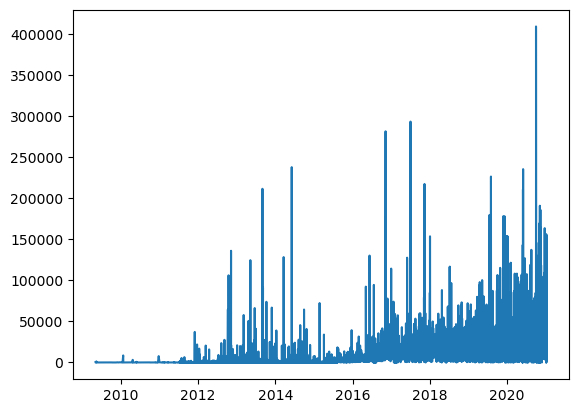

In [3]:
plt.plot(tweets_df['date'], tweets_df['retweets'])
plt.show()
plt.close()

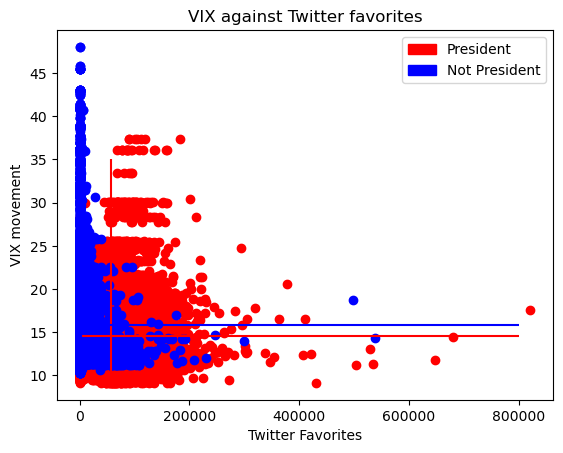

In [45]:
plt.figure()
for p in ["red", "blue"]:
    plt.scatter(merged['favorites'][merged["isPresident"] == (p == "red")], merged['VIXCLS'][merged["isPresident"] == (p == "red")], c=p) # red if president
    

for p in ["red", "blue"]:
    plt.vlines(np.mean(merged['favorites'][merged["isPresident"] == (p == "red")]), ymin=10, ymax=35, colors=p)
    plt.hlines(np.mean(merged['VIXCLS'][merged["isPresident"] == (p == "red")]), xmin=0, xmax=800_000, colors=p)
    
p_patch = mpatches.Patch(color="red", label="President")
np_patch = mpatches.Patch(color="blue", label="Not President")

plt.legend(handles=[p_patch, np_patch])    

plt.title("VIX against Twitter favorites")
plt.xlabel("Twitter Favorites")
plt.ylabel("VIX movement")
plt.show()
plt.close()

## Analysis

### Imports

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [ ]:
X = merged['text']
y = merged['VIXCLS']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english') # Handles tokenization internally
X_train_vectorized = vectorizer.fit_transform(X_train)

# Train a Linear Regression model
model = Ridge(alpha=0.8)
model.fit(X_train_vectorized, y_train)

# 3. Make predictions on the test set
X_test_vectorized = vectorizer.transform(X_test)
y_pred = model.predict(X_test_vectorized)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))

MSE: 13.67789924821801
R^2: 0.1625372481547015


In [ ]:
X = merged['text'][merged["isPresident"]]
y = merged['VIXCLS'][merged["isPresident"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english') # Handles tokenization internally
X_train_vectorized = vectorizer.fit_transform(X_train)

# Train a Linear Regression model
model = Ridge(alpha=0.8)
model.fit(X_train_vectorized, y_train)

# 3. Make predictions on the test set
X_test_vectorized = vectorizer.transform(X_test)
y_pred = model.predict(X_test_vectorized)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))
print("Intercept:", model.intercept_)

MSE: 12.481399605474625
R^2: 0.08036307644972052
InterceptL 13.867633775873658


In [ ]:
X = merged['text'][~merged["isPresident"]]
y = merged['VIXCLS'][~merged["isPresident"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

vectorizer = TfidfVectorizer(lowercase=True, stop_words='english') # Handles tokenization internally
X_train_vectorized = vectorizer.fit_transform(X_train)

# Train a Linear Regression model
model = Ridge(alpha=0.8)
model.fit(X_train_vectorized, y_train)

# 3. Make predictions on the test set
X_test_vectorized = vectorizer.transform(X_test)
y_pred = model.predict(X_test_vectorized)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R^2:", r2_score(y_test, y_pred))
print("Intercept:", model.intercept_)

MSE: 14.623994587105619
R^2: 0.17755339928573877
InterceptL 15.723314613103014
